In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("train(1)(train(1)).csv")

# Verify missing values
missing_info = df.isnull().sum()
print("Missing Values per Column:")
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "No missing values found.")

# Quick summary of data types
print("\nData Types:")
print(df.dtypes)

Missing Values per Column:
No missing values found.

Data Types:
id                 int64
date              object
price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


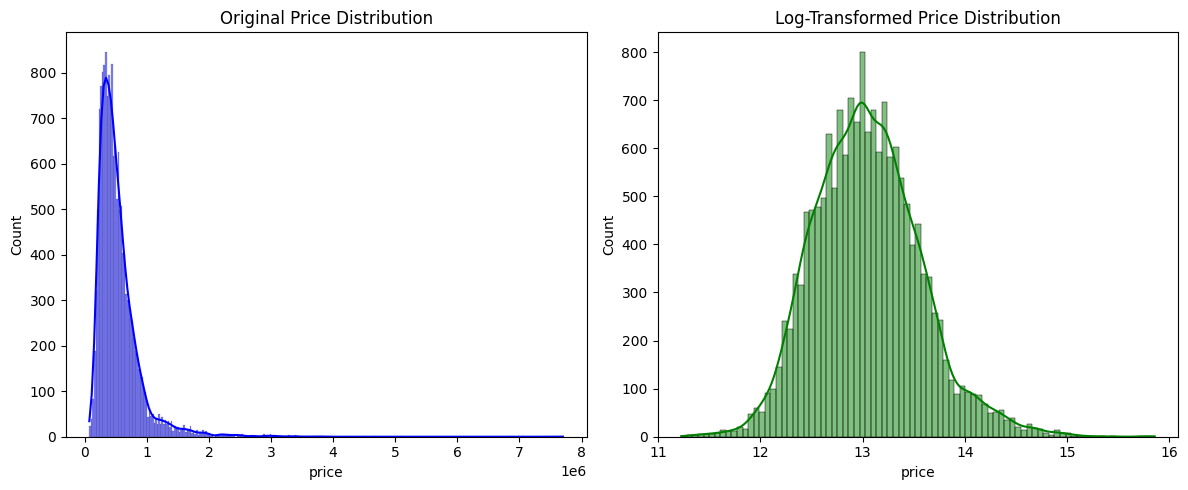

In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Original Price Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, color='green')
plt.title('Log-Transformed Price Distribution')

plt.tight_layout()
plt.show()

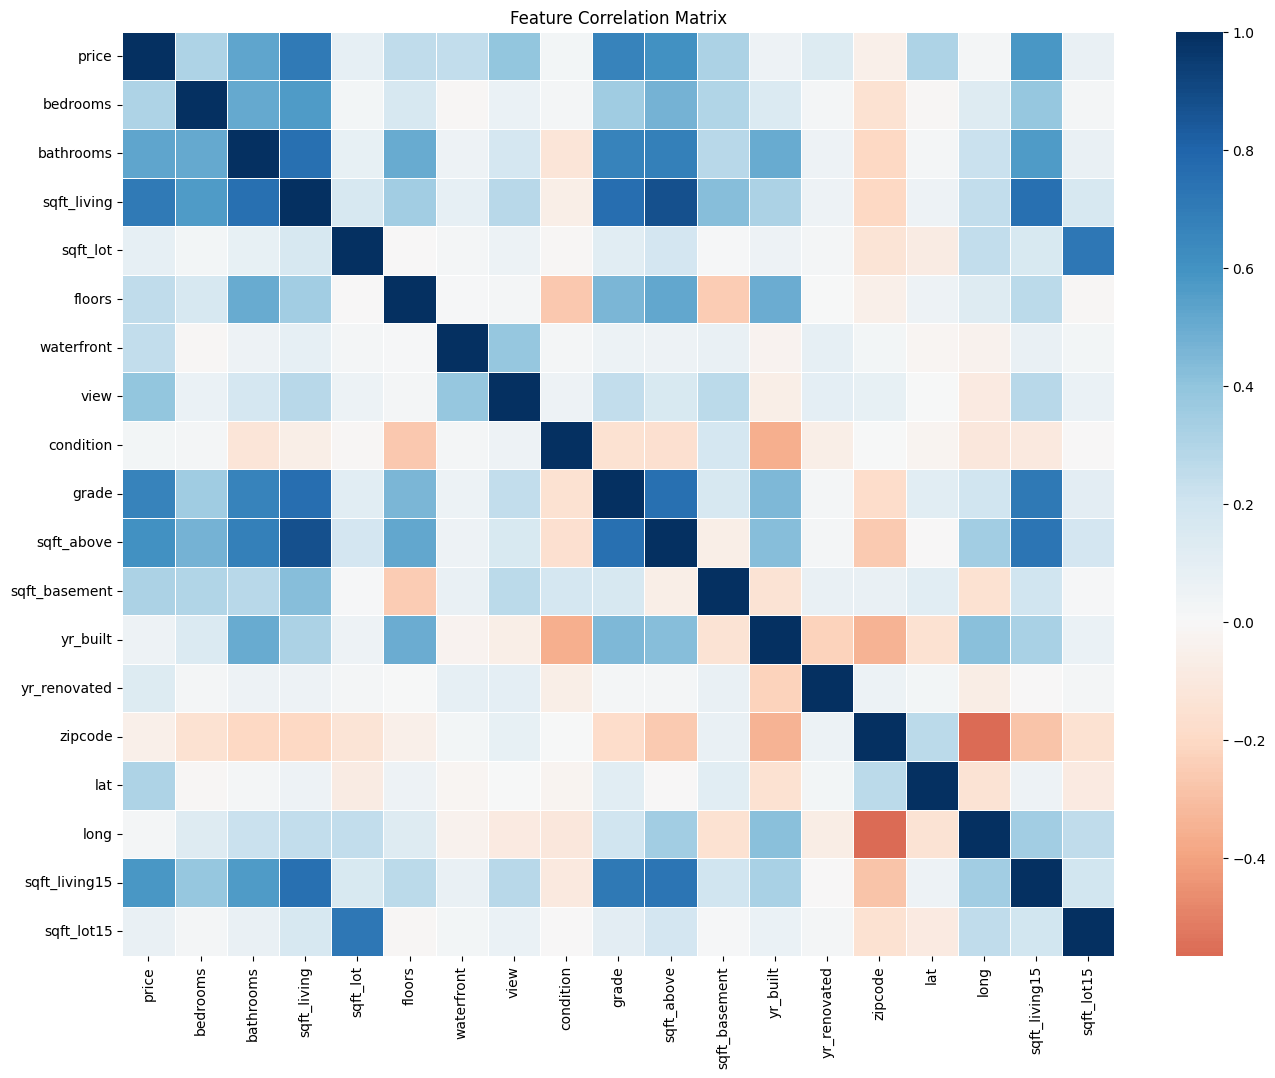

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-meaningful / non-numeric columns
corr_df = df.drop(columns=['date', 'id'])

correlation_matrix = corr_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    cmap='RdBu',
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.show()


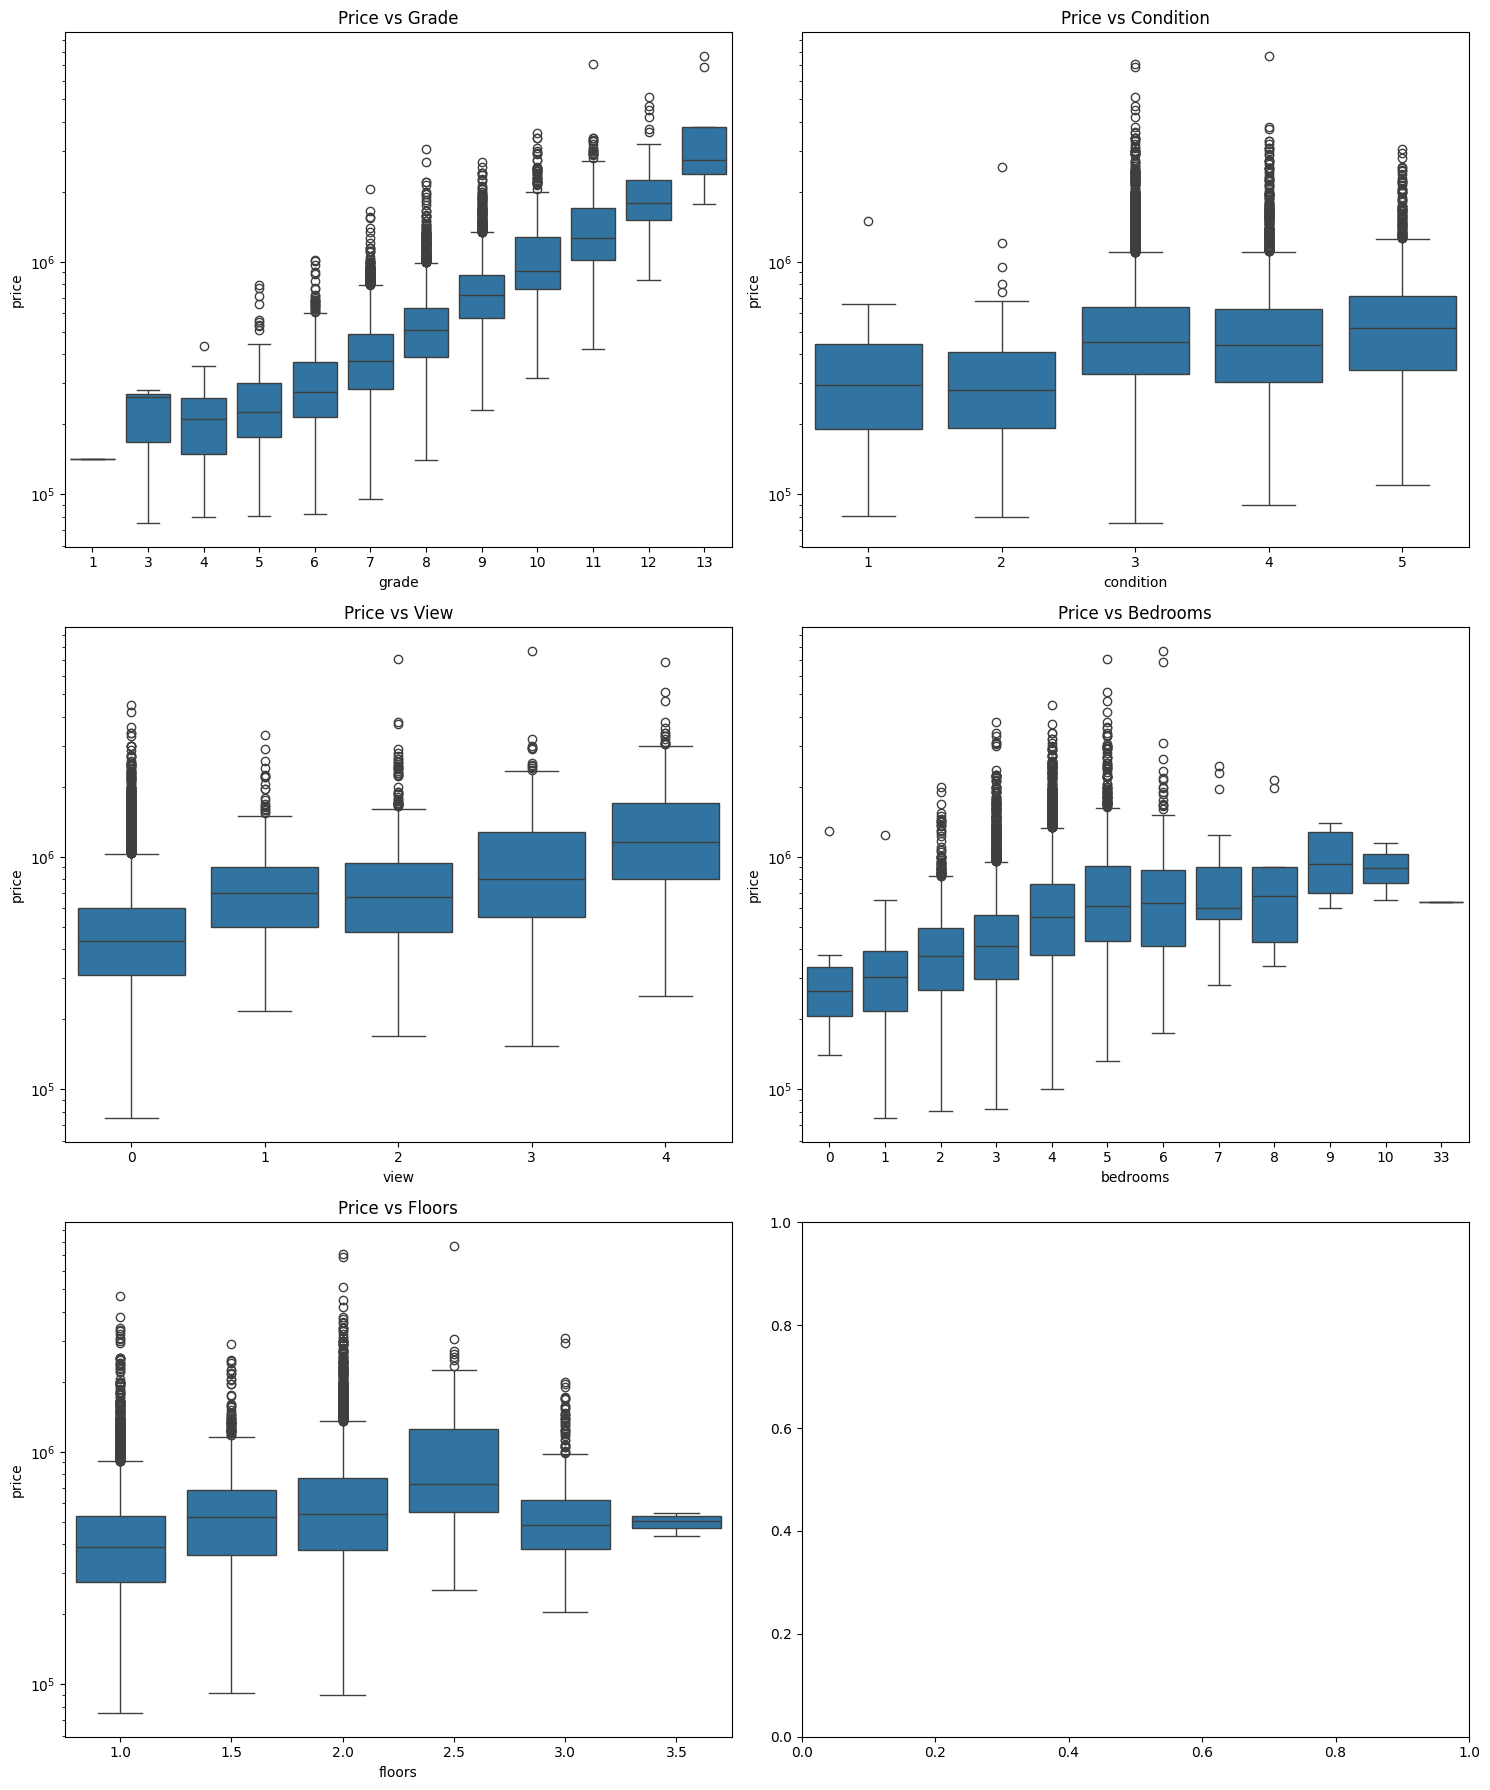

In [5]:
cols_to_plot = ['grade', 'condition', 'view', 'bedrooms', 'floors']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i])
    axes[i].set_title(f'Price vs {col.capitalize()}')
    axes[i].set_yscale('log') # Log scale helps handle price outliers visually

plt.tight_layout()
plt.show()

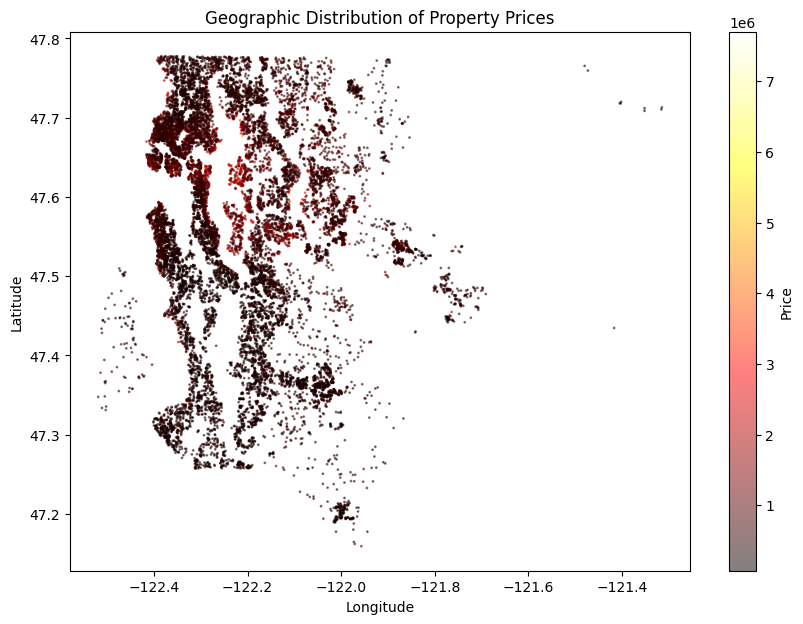

In [6]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['long'], df['lat'], c=df['price'], cmap='hot', s=1, alpha=0.5)
plt.colorbar(scatter, label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Property Prices')
plt.show()

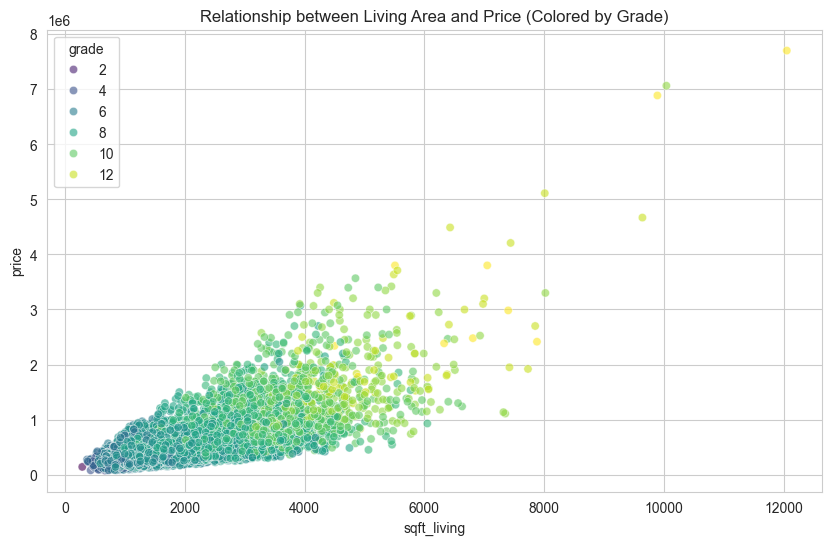

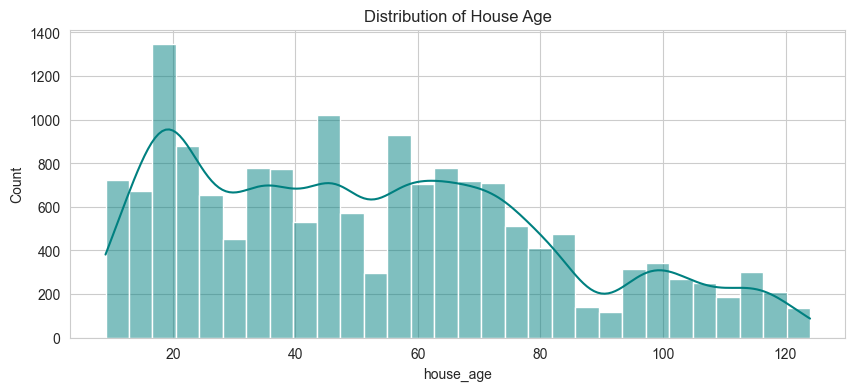

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the aesthetics
sns.set_style("whitegrid")

# Plotting Sqft_living vs Price with a hue for Grade
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_living', y='price', hue='grade', palette='viridis', alpha=0.6)
plt.title('Relationship between Living Area and Price (Colored by Grade)')
plt.show()

# Distribution of Age (Derived from yr_built)
df['house_age'] = 2024 - df['yr_built']
plt.figure(figsize=(10, 4))
sns.histplot(df['house_age'], bins=30, kde=True, color='teal')
plt.title('Distribution of House Age')
plt.show()

In [8]:
# 1. Convert Date
df['date'] = pd.to_datetime(df['date'])

# 2. Adjust Floors and Bathrooms (Converting to Int if they are whole numbers, or keeping as float)
# In this dataset, floors and bathrooms often come in .5 increments, so float is technically correct.
# However, we can ensure they are properly cast.
df['bathrooms'] = df['bathrooms'].astype(float)
df['floors'] = df['floors'].astype(float)

# 3. Simplify yr_renovated to a binary "is_renovated" or age since renovation
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

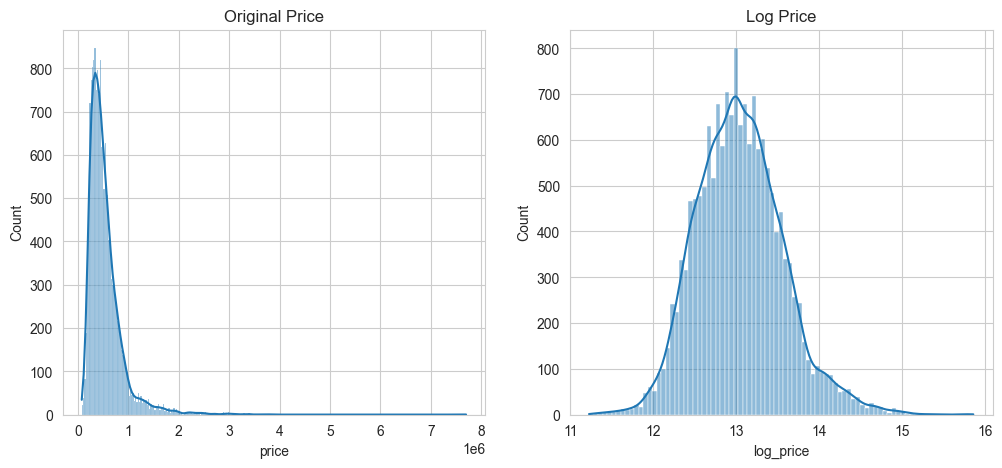

In [9]:
# Apply log transformation
df['log_price'] = np.log1p(df['price'])

# Visualize the effect
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['price'], ax=ax[0], kde=True).set_title('Original Price')
sns.histplot(df['log_price'], ax=ax[1], kde=True).set_title('Log Price')
plt.show()

In [10]:
# Calculate correlation with the target
corr_with_price = df.corr()['log_price'].sort_values(ascending=False)
print("Correlation with Log Price:\n", corr_with_price)

# Dropping columns that have no predictive value or cause data leakage
# 'id' is just an index.
# 'date' is hard for a regression model to use without complex encoding.
# 'price' must be dropped because we are using 'log_price' as the target.
# 'zipcode' is categorical and should be handled separately or dropped if lat/long is used.

cols_to_drop = ['id', 'date', 'price', 'zipcode']
df_final = df.drop(columns=cols_to_drop)

print(f"\nRemaining columns for training: {df_final.columns.tolist()}")

Correlation with Log Price:
 log_price        1.000000
price            0.893444
grade            0.700249
sqft_living      0.693377
sqft_living15    0.615312
sqft_above       0.596904
bathrooms        0.550492
lat              0.452503
view             0.340868
bedrooms         0.337664
sqft_basement    0.315438
floors           0.305348
waterfront       0.161167
yr_renovated     0.119410
is_renovated     0.119009
sqft_lot         0.098102
sqft_lot15       0.086677
yr_built         0.076376
long             0.052900
condition        0.033024
date             0.003830
id              -0.007350
zipcode         -0.039803
house_age       -0.076376
Name: log_price, dtype: float64

Remaining columns for training: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'is_renovated', 'log_price']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("train(1)(train(1)).csv")

# 1. Ensure numeric types are correctly recognized
# Converting floors and bathrooms explicitly to float as they often have .5 values
df['bathrooms'] = df['bathrooms'].astype(float)
df['floors'] = df['floors'].astype(float)

# 2. Range Analysis for ALL numeric columns (int64 and float64)
numeric_cols = df.select_dtypes(include=[np.number]).columns
ranges = df[numeric_cols].agg(['min', 'max'])
ranges.loc['range'] = ranges.loc['max'] - ranges.loc['min']

print("--- Range Analysis for All Numeric Columns ---")
print(ranges.transpose())

--- Range Analysis for All Numeric Columns ---
                        min           max         range
id             1.000102e+06  9.900000e+09  9.899000e+09
price          7.500000e+04  7.700000e+06  7.625000e+06
bedrooms       0.000000e+00  3.300000e+01  3.300000e+01
bathrooms      0.000000e+00  8.000000e+00  8.000000e+00
sqft_living    2.900000e+02  1.205000e+04  1.176000e+04
sqft_lot       5.200000e+02  1.164794e+06  1.164274e+06
floors         1.000000e+00  3.500000e+00  2.500000e+00
waterfront     0.000000e+00  1.000000e+00  1.000000e+00
view           0.000000e+00  4.000000e+00  4.000000e+00
condition      1.000000e+00  5.000000e+00  4.000000e+00
grade          1.000000e+00  1.300000e+01  1.200000e+01
sqft_above     2.900000e+02  8.860000e+03  8.570000e+03
sqft_basement  0.000000e+00  4.820000e+03  4.820000e+03
yr_built       1.900000e+03  2.015000e+03  1.150000e+02
yr_renovated   0.000000e+00  2.015000e+03  2.015000e+03
zipcode        9.800100e+04  9.819900e+04  1.980000e+02
l

In [12]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("train(1)(train(1)).csv")

# --- 1. Target Transformation ---
# Price is highly skewed; log transformation is standard practice
df['log_price'] = np.log1p(df['price'])

# --- 2. Temporal Features ---
# Convert year built to age (assuming current year is 2024 for relevance)
df['house_age'] = 2024 - df['yr_built']
# Create a binary flag for renovated houses
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# --- 3. Log Transformations for Skewed Area Features ---
# Using np.log1p (log(1+x)) to safely handle any potential zeros (like sqft_basement)
area_cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
for col in area_cols:
    df[f'log_{col}'] = np.log1p(df[col])

# Note: We now have log versions of these area features which are more normally distributed.

In [13]:
# Calculate correlation with the target
correlations = df.corr(numeric_only=True)['log_price'].sort_values(ascending=False)

print("Correlation with Log Price (Including Transformations):")
print(correlations)

Correlation with Log Price (Including Transformations):
log_price            1.000000
price                0.893444
grade                0.700249
sqft_living          0.693377
log_sqft_living      0.671430
sqft_living15        0.615312
log_sqft_living15    0.603558
sqft_above           0.596904
log_sqft_above       0.581300
bathrooms            0.550492
lat                  0.452503
view                 0.340868
bedrooms             0.337664
sqft_basement        0.315438
floors               0.305348
log_sqft_basement    0.239789
waterfront           0.161167
log_sqft_lot         0.134184
log_sqft_lot15       0.119696
yr_renovated         0.119410
is_renovated         0.119009
sqft_lot             0.098102
sqft_lot15           0.086677
yr_built             0.076376
long                 0.052900
condition            0.033024
id                  -0.007350
zipcode             -0.039803
house_age           -0.076376
Name: log_price, dtype: float64


In [14]:
# List of columns to drop based on your correlation results
# 1. Low Correlation (|r| < 0.1)
low_corr_cols = ['sqft_lot', 'sqft_lot15', 'yr_built', 'condition', 'zipcode', 'house_age']

# 2. Administrative/Redundant
admin_redundant_cols = ['id', 'date', 'price', 'yr_renovated']

# 3. Non-Log area columns (to keep only the log versions for better model performance)
raw_area_cols = ['sqft_living', 'sqft_living15', 'sqft_above', 'sqft_basement']

# Combine all drop lists
all_to_drop = list(set(low_corr_cols + admin_redundant_cols + raw_area_cols))

# Execute the drop
df_final = df.drop(columns=all_to_drop)

# Final check: Ensure lat/long and log_price are still there
print(f"Final column count: {len(df_final.columns)}")
print("Remaining features:", df_final.columns.tolist())

# Save for the next stage
df_final.to_csv('final_processed_tabular.csv', index=False)

Final column count: 16
Remaining features: ['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'grade', 'lat', 'long', 'log_price', 'is_renovated', 'log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement', 'log_sqft_living15', 'log_sqft_lot15']


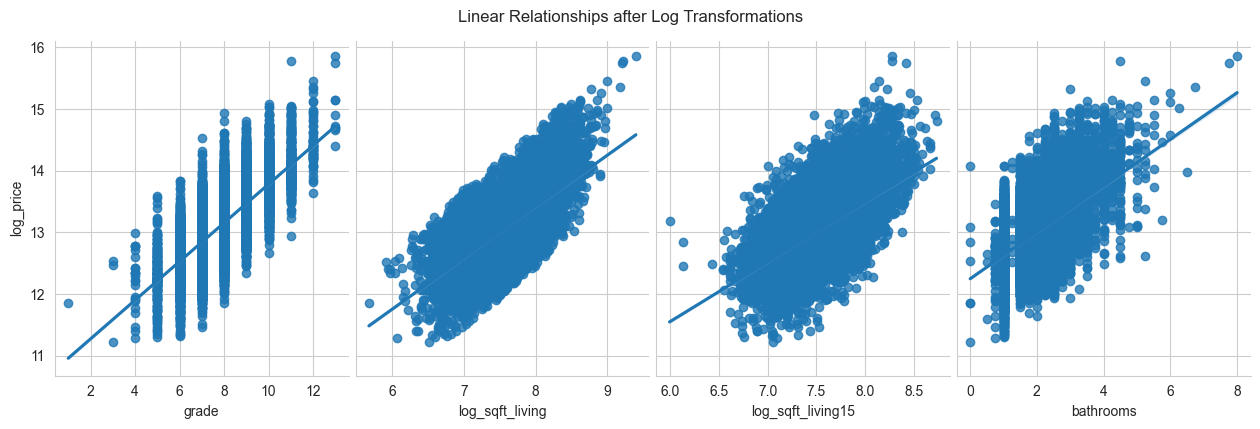

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the top 4 predictors
top_predictors = ['grade', 'log_sqft_living', 'log_sqft_living15', 'bathrooms']

sns.pairplot(df_final, x_vars=top_predictors, y_vars='log_price', height=4, aspect=0.8, kind='reg')
plt.suptitle("Linear Relationships after Log Transformations", y=1.05)
plt.show()

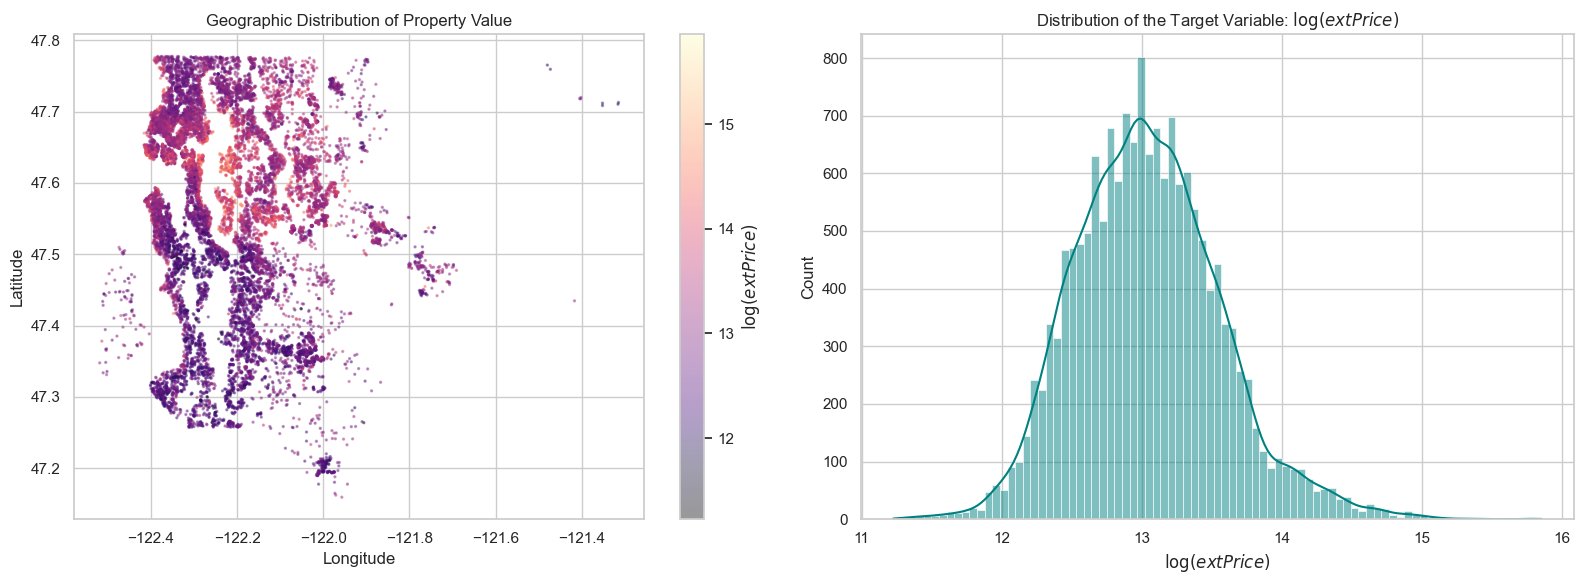

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('final_processed_tabular.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create a multi-plot figure for high-level overview
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Geospatial Heatmap
# Using lat/long to see price density
scatter = axes[0].scatter(df['long'], df['lat'], c=df['log_price'], 
                         cmap='magma', s=2, alpha=0.4)
fig.colorbar(scatter, ax=axes[0], label='$\log(\text{Price})$')
axes[0].set_title('Geographic Distribution of Property Value')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot 2: Log Price Distribution
sns.histplot(df['log_price'], kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribution of the Target Variable: $\log(\text{Price})$')
axes[1].set_xlabel('$\log(\text{Price})$')

plt.tight_layout()
plt.savefig('geospatial_and_target_dist.png')

C:\Users\aksha\AppData\Local\Temp\ipykernel_13128\2151196329.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\aksha\AppData\Local\Temp\ipykernel_13128\2151196329.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\aksha\AppData\Local\Temp\ipykernel_13128\2151196329.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\aksha\AppData\Local\Temp\ipykernel_13128\2151196329.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

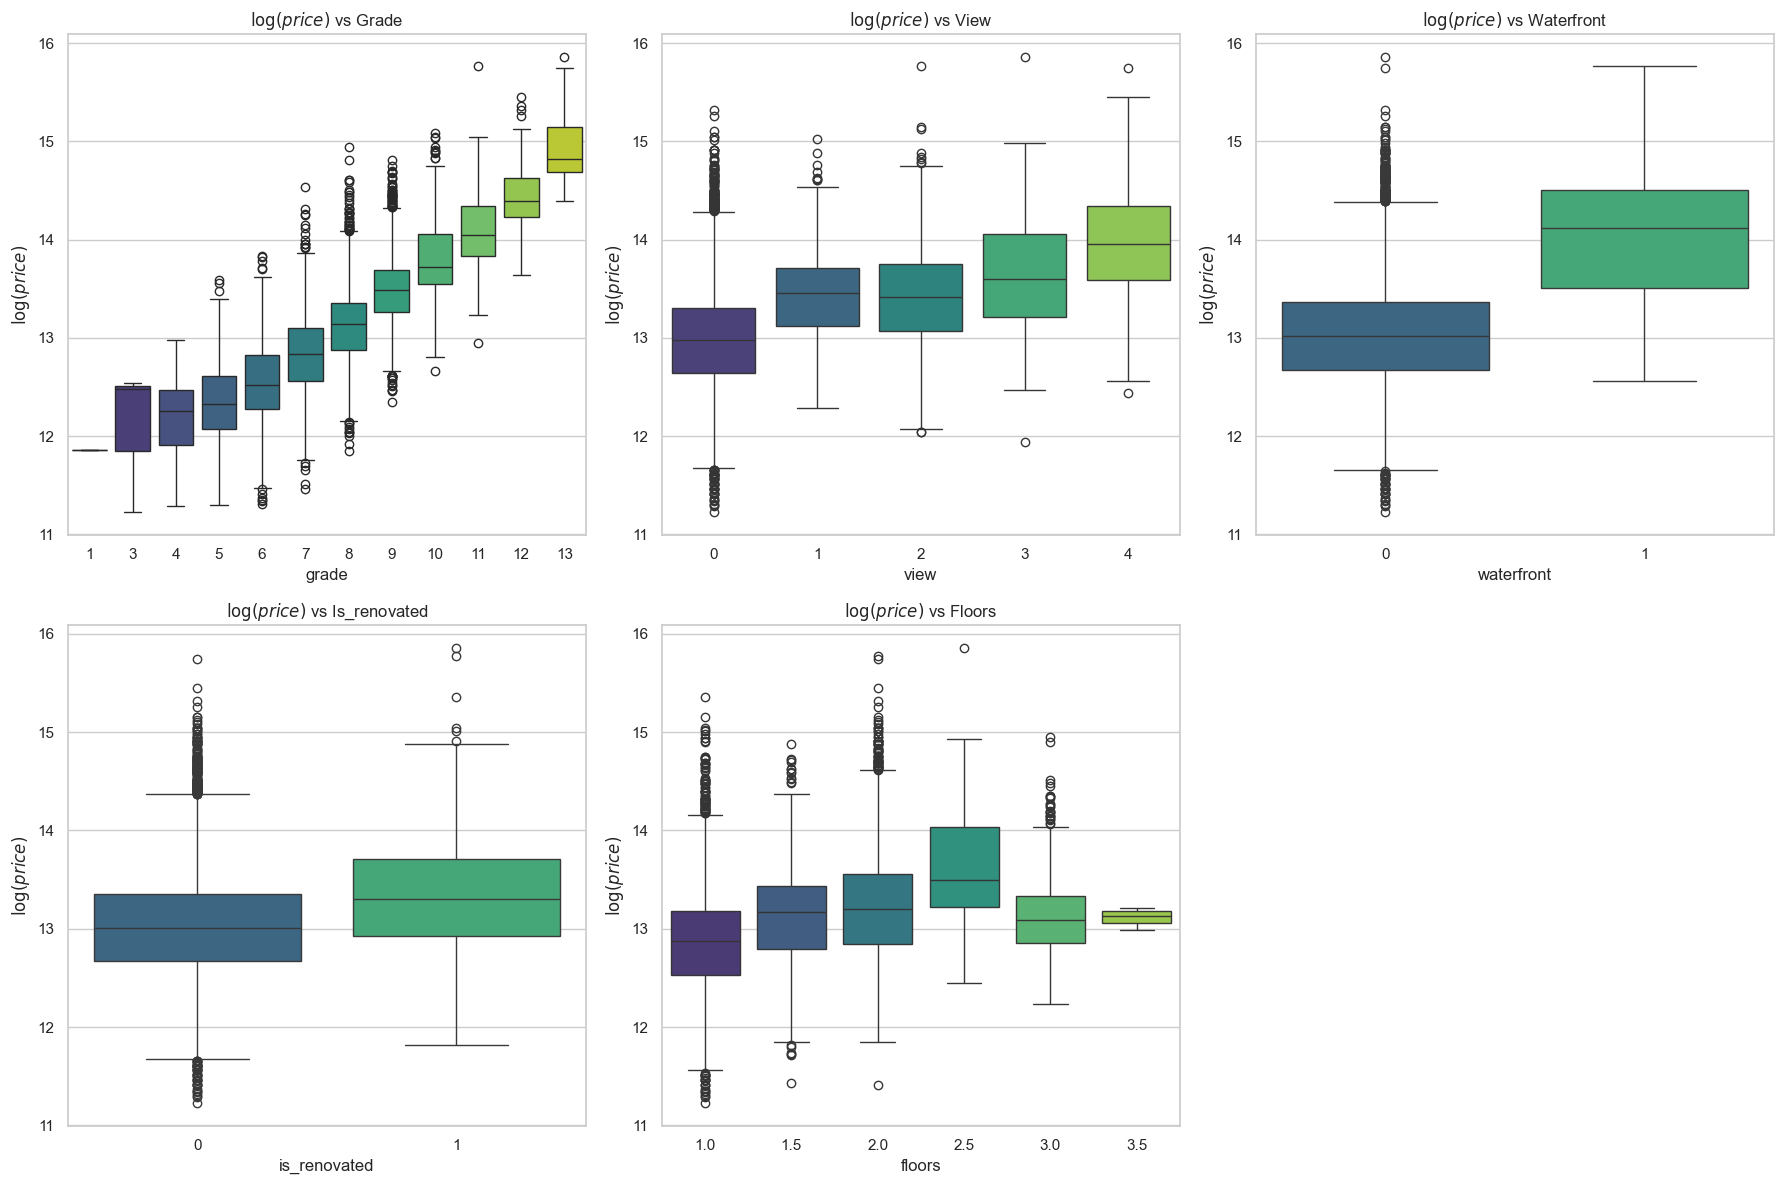

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure log_price exists
if 'log_price' not in df.columns:
    df['log_price'] = np.log1p(df['price'])

categorical_features = ['grade', 'view', 'waterfront', 'is_renovated', 'floors']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.boxplot(
        x=feature,
        y='log_price',
        data=df,
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'$\\log(price)$ vs {feature.capitalize()}')
    axes[i].set_ylabel('$\\log(price)$')

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('categorical_boxplots.png', dpi=300)
plt.show()


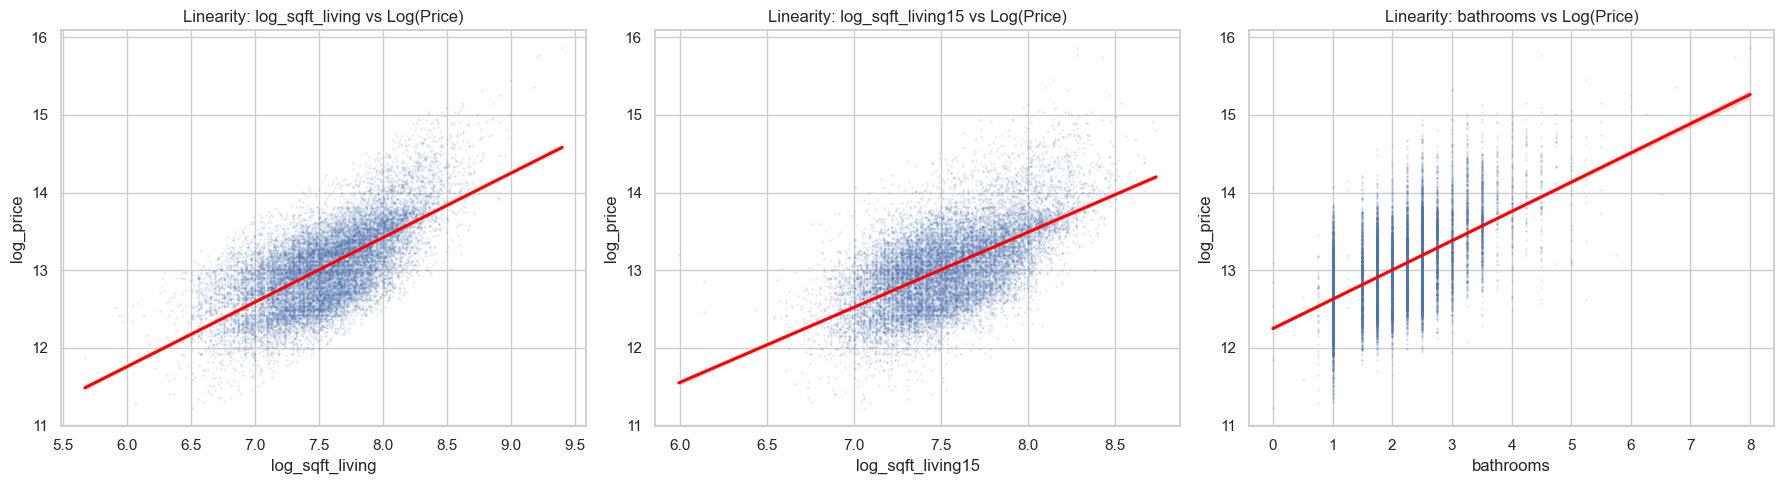

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = ['log_sqft_living', 'log_sqft_living15', 'bathrooms']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(continuous_features):
    sns.regplot(
        x=feature,
        y='log_price',
        data=df,
        ax=axes[i],
        scatter_kws={'alpha': 0.1, 's': 1},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f'Linearity: {feature} vs Log(Price)')

plt.tight_layout()
plt.savefig('continuous_regression_plots.png', dpi=300)
plt.show()


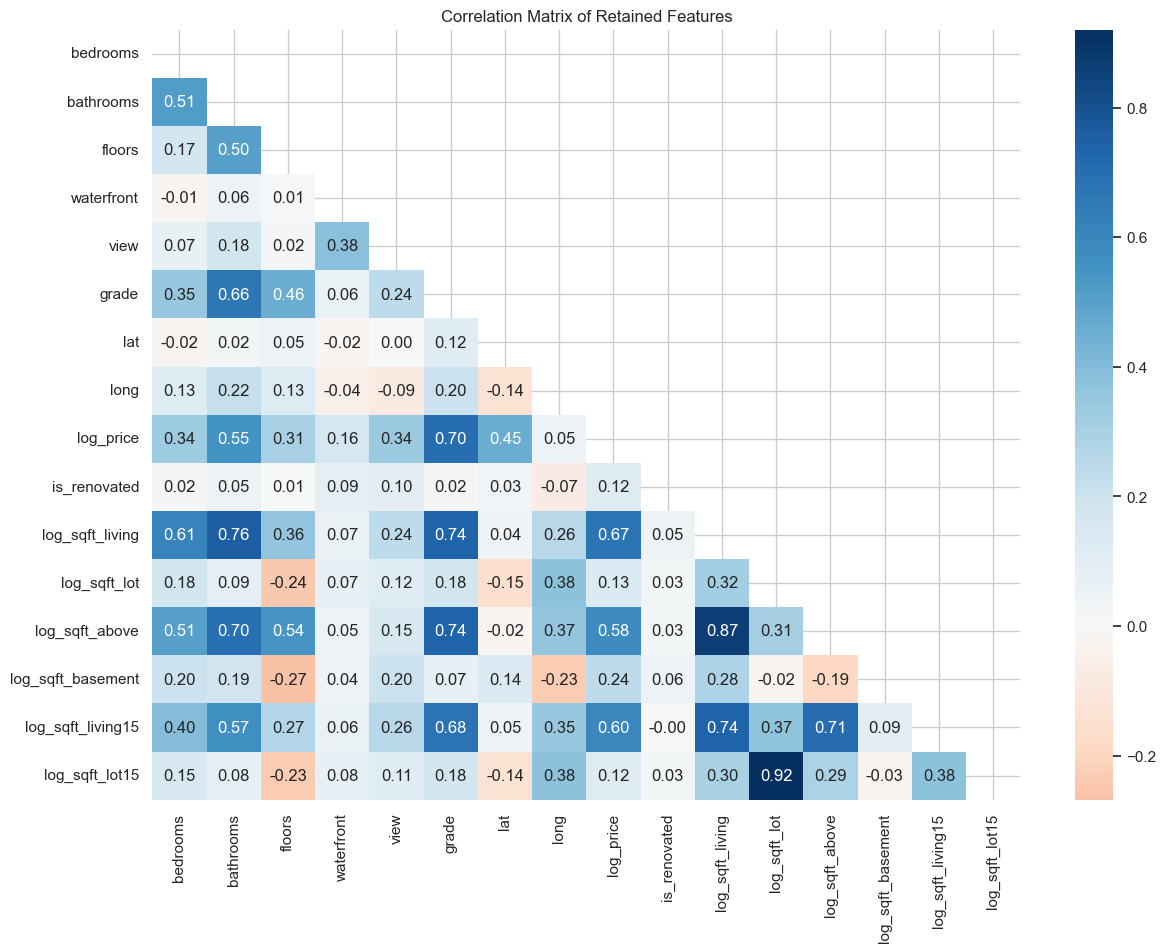

In [24]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title("Correlation Matrix of Retained Features")
plt.savefig('final_correlation_heatmap.png')